In [205]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0    = "../20260404-experiment/sweat.csv"   # Defective — NH3 pin disconnected (miswired from start)
SWEAT_1    = "../20260405-experiment/sweat.csv"   
SWEAT_2    = "../20260331-experiment/sweat.csv"
BLOOD_0    = "../20260406-experiment/1.5_blood.csv"
BLOOD_1    = "../20260406-experiment/1.5_blood_2.csv"
VALIDATION = "../testrun-h2s-st-2/readings_20260312_144332.csv"  


SPEC     = ["h2s_ppm", "etoh_ppm"]
ENV      = ["temp_C", "rh_pct"]
CHANNELS = SPEC + ENV

EMA_SPAN = 30   

# ── SPEC sensor PPM constants ─────────────────────────────────────────────────
# PPM formula:
#   m    = sensitivity_code [nA/ppm] × TIA_gain [kΩ] × 1e-6  →  [V/ppm]
#   ppm  = clip((Vgas + vgas_offset − Vref) / m, lower=0) × ppm_scale

H2S_SENSITIVITY_CODE  = 216.09  
H2S_TIA_GAIN          = 49.9    
M_H2S                 = H2S_SENSITIVITY_CODE * H2S_TIA_GAIN * 1e-6   
H2S_VGAS_OFFSET       = 0.0     
H2S_SCALE             = 1.5     

ETOH_SENSITIVITY_CODE = 21.5    
ETOH_TIA_GAIN         = 249.0   
M_ETOH                = ETOH_SENSITIVITY_CODE * ETOH_TIA_GAIN * 1e-6  
ETOH_VGAS_OFFSET      = +0.100  
ETOH_SCALE            = 1.0     


In [206]:
def calc_spec_ppm(df, vgas_col, vref_col, m, vgas_offset=0.0, ppm_scale=1.0):
    """
    Compute corrected PPM from raw Vgas and Vref columns.

    Formula:
        ppm = clip((Vgas + vgas_offset − Vref) / m, lower=0) × ppm_scale

    Parameters
    ----------
    df           : DataFrame containing vgas_col and vref_col
    vgas_col     : column name for gas electrode voltage
    vref_col     : column name for reference electrode voltage
    m            : sensitivity slope [V/ppm]  (= sensitivity_code × TIA_gain × 1e-6)
    vgas_offset  : additive voltage correction to Vgas before division [V]
    ppm_scale    : multiplicative correction applied after PPM calculation
    """
    ppm = ((df[vgas_col] + vgas_offset) - df[vref_col]) / m
    return ppm.clip(lower=0) * ppm_scale

In [207]:
import pandas as pd
import matplotlib.pyplot as plt

VGAS_COLS = ["h2s_vgas", "h2s_vref", "etoh_vgas", "etoh_vref"]

def load(path):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in CHANNELS + VGAS_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["h2s_ppm"]  = calc_spec_ppm(df, "h2s_vgas",  "h2s_vref",  M_H2S,
                                    vgas_offset=H2S_VGAS_OFFSET,  ppm_scale=H2S_SCALE)
    df["etoh_ppm"] = calc_spec_ppm(df, "etoh_vgas", "etoh_vref", M_ETOH,
                                    vgas_offset=ETOH_VGAS_OFFSET, ppm_scale=ETOH_SCALE)

    return df.reset_index(drop=True)

sweat_0  = load(SWEAT_0)
sweat_1  = load(SWEAT_1)
sweat_2  = load(SWEAT_2)
blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1)

print({
    "sweat_0": len(sweat_0),
    "sweat_1": len(sweat_1),
    "sweat_2": len(sweat_2),
    "blood_0": len(blood_0),
    "blood_1": len(blood_1),
})

{'sweat_0': 4084, 'sweat_1': 6299, 'sweat_2': 5574, 'blood_0': 3666, 'blood_1': 3618}


## Initial Visualization

Raw SPEC and ENV signals across all datasets in scope: **Sweat 1, Blood 0, Blood 1**.
SWEAT_0 excluded (defective wiring). SWEAT_2 excluded.

PPM values are recomputed from raw Vgas/Vref columns — firmware values are not used:
- **H2S**: `ppm = clip((Vgas − Vref) / M_H2S, 0) × 1.5` (scale correction)
- **EtOH**: `ppm = clip((Vgas + 0.100 − Vref) / M_ETOH, 0)` (Vgas offset per datasheet)

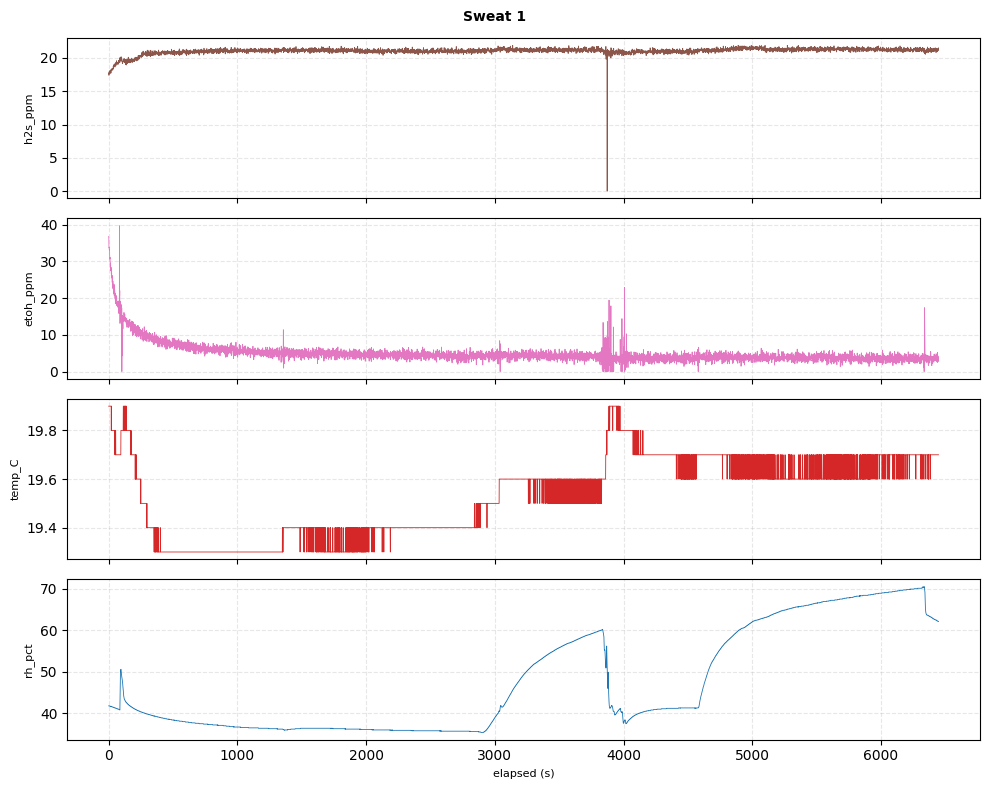

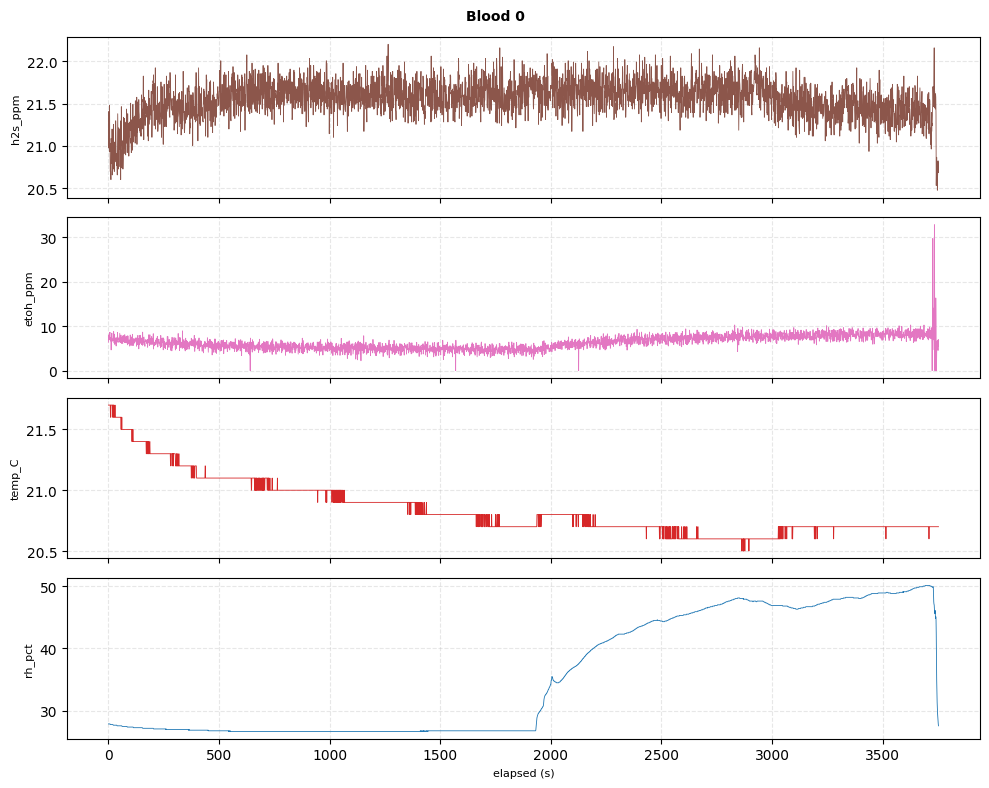

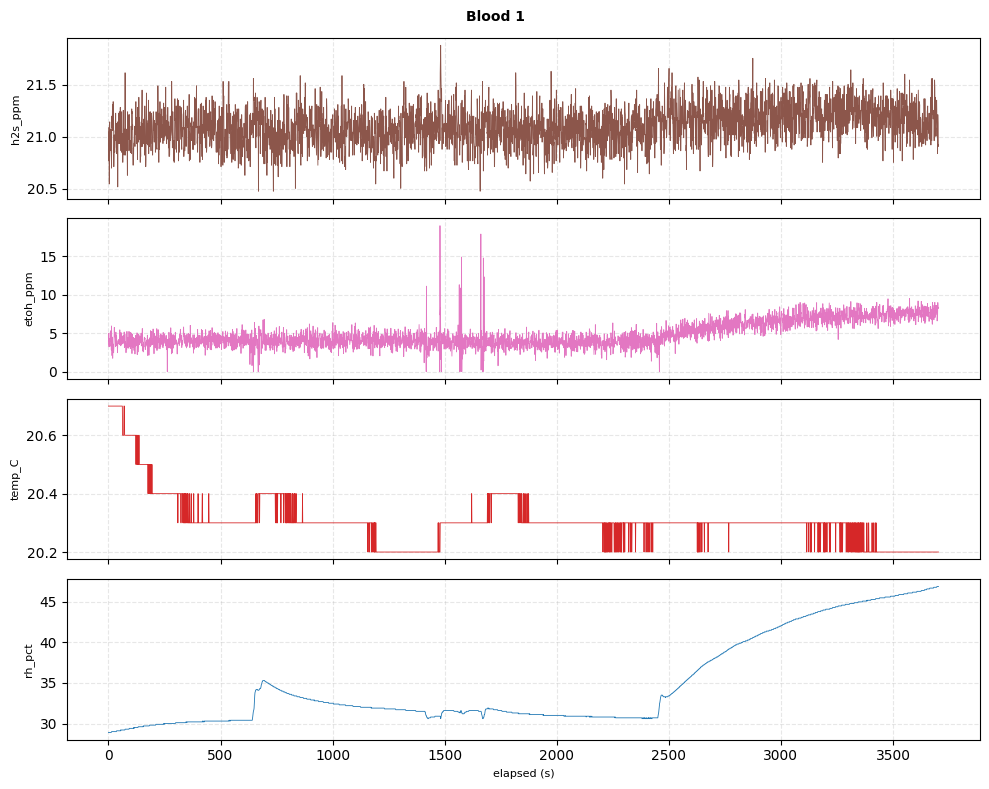

In [208]:
COLORS = {
    "h2s_ppm":  "tab:brown",
    "etoh_ppm": "tab:pink",
    "temp_C":   "tab:red",
    "rh_pct":   "tab:blue",
}

datasets = {
    "Sweat 1": sweat_1,
    "Blood 0": blood_0,
    "Blood 1": blood_1,
}

def plot_raw(name, df):
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")
    for ax, col in zip(axes, CHANNELS):
        ax.plot(df["elapsed_s"], df[col], color=COLORS[col], linewidth=0.6)
        ax.set_ylabel(col, fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_raw(name, df)

## Outlier Detection and Handling

Applied to **SPEC sensors only** (H2S ppm, EtOH ppm). ENV channels (Temp, RH) from the HDC302x are hardware-filtered and rarely spike.

**Detection** — a point is flagged if either detector triggers:

| Detector | Method | Parameters |
|----------|--------|------------|
| IQR | Rolling IQR fence — flag if outside Q1 − k·IQR or Q3 + k·IQR | window=60 s, k=2.0 |
| ROC | Rate-of-change — flag if \|Δ\| exceeds z_thresh rolling std devs above local mean | window=60 s, z_thresh=3.0 |

**Handling** — flagged samples are replaced using **rate-of-change extrapolation from previous clean readings only** (causal — no future data used):

1. Flagged samples are set to NaN.
2. For each gap, the average slope is computed from the last N clean samples *before* the gap.
3. The gap is filled by projecting that slope forward, up to `max_gap` samples.
4. Any gaps without sufficient history are forward-filled from the last clean value.

In [209]:
import numpy as np

# ── Outlier detection helpers ─────────────────────────────────────────────────

def detect_outliers_iqr(series: pd.Series, window: int = 60, k: float = 2.0) -> pd.Series:
    """
    Rolling IQR outlier detection (causal — no future data).
    Returns boolean Series: True = outlier.
    k=1.5 is standard; 2.0–3.0 is more conservative (fewer false positives).
    """
    Q1 = series.rolling(window=window, min_periods=1).quantile(0.25)
    Q3 = series.rolling(window=window, min_periods=1).quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k * IQR) | (series > Q3 + k * IQR)


def detect_outliers_roc(series: pd.Series, window: int = 60, z_thresh: float = 3.0) -> pd.Series:
    """
    Rate-of-change outlier detection (causal).
    Flags samples where |Δ from previous sample| is z_thresh std devs above
    the rolling mean rate of change.
    Returns boolean Series: True = outlier.
    """
    roc = series.diff().abs()
    rolling_mean = roc.rolling(window=window, min_periods=1).mean()
    rolling_std  = roc.rolling(window=window, min_periods=1).std().replace(0, np.nan)
    z_score = (roc - rolling_mean) / rolling_std
    return z_score > z_thresh


def handle_outliers(series: pd.Series, mask: pd.Series,
                    roc_window: int = 5, max_gap: int = 30) -> pd.Series:
    """
    Replace flagged samples using rate-of-change extrapolation from previous
    clean readings only (causal — no future data used).

    For each flagged gap:
      1. Collect the last `roc_window` clean samples before the gap.
      2. Compute the average slope (change per sample) from those readings.
      3. Extrapolate forward up to `max_gap` samples.
    Gaps with insufficient history (< 2 clean samples before them) are
    forward-filled from the last clean value.
    """
    cleaned = series.copy().astype(float)
    cleaned[mask] = np.nan
    values = cleaned.to_numpy(dtype=float)

    for i in range(len(values)):
        if not np.isnan(values[i]):
            continue

        # Collect clean sample indices before this gap
        before_idx = [j for j in range(i - 1, -1, -1) if not np.isnan(values[j])]
        if len(before_idx) < 2:
            continue  # not enough history — leave for ffill below

        # Average slope from last roc_window clean samples
        anchor = before_idx[:roc_window]
        slopes = [values[anchor[k]] - values[anchor[k + 1]] for k in range(len(anchor) - 1)]
        avg_slope = np.mean(slopes)

        # Extrapolate forward until gap ends or max_gap reached
        j, gap_count = i, 0
        while j < len(values) and np.isnan(values[j]) and gap_count < max_gap:
            values[j] = values[before_idx[0]] + avg_slope * (j - before_idx[0])
            gap_count += 1
            j += 1

    cleaned = pd.Series(values, index=series.index)
    return cleaned.ffill().bfill()  # catch any remaining edge NaNs


# ── Per-dataset outlier config ────────────────────────────────────────────────
OUTLIER_CONFIG = {
    "Sweat 1": {"iqr_window": 60, "iqr_k": 2.0, "roc_window": 60, "roc_z": 3.0},
    "Blood 0": {"iqr_window": 60, "iqr_k": 2.0, "roc_window": 60, "roc_z": 3.0},
    "Blood 1": {"iqr_window": 60, "iqr_k": 2.0, "roc_window": 60, "roc_z": 3.0},
}

# ── Apply detection and handle ────────────────────────────────────────────────
outlier_info = {}   # {name: {col: {"mask": Series, "patched": Series}}}

for name, df in datasets.items():
    cfg = OUTLIER_CONFIG[name]
    outlier_info[name] = {}
    for col in SPEC:
        mask_iqr = detect_outliers_iqr(df[col], window=cfg["iqr_window"], k=cfg["iqr_k"])
        mask_roc = detect_outliers_roc(df[col], window=cfg["roc_window"], z_thresh=cfg["roc_z"])
        combined = mask_iqr | mask_roc
        patched  = handle_outliers(df[col], combined)
        outlier_info[name][col] = {"mask": combined, "patched": patched}
        n = combined.sum()
        print(f"{name:8}  {col:10}  outliers flagged: {n:4d}  ({100*n/len(df):.1f}%)")

Sweat 1   h2s_ppm     outliers flagged:   60  (1.0%)
Sweat 1   etoh_ppm    outliers flagged:  109  (1.7%)
Blood 0   h2s_ppm     outliers flagged:   38  (1.0%)
Blood 0   etoh_ppm    outliers flagged:   41  (1.1%)
Blood 1   h2s_ppm     outliers flagged:   38  (1.1%)
Blood 1   etoh_ppm    outliers flagged:   68  (1.9%)


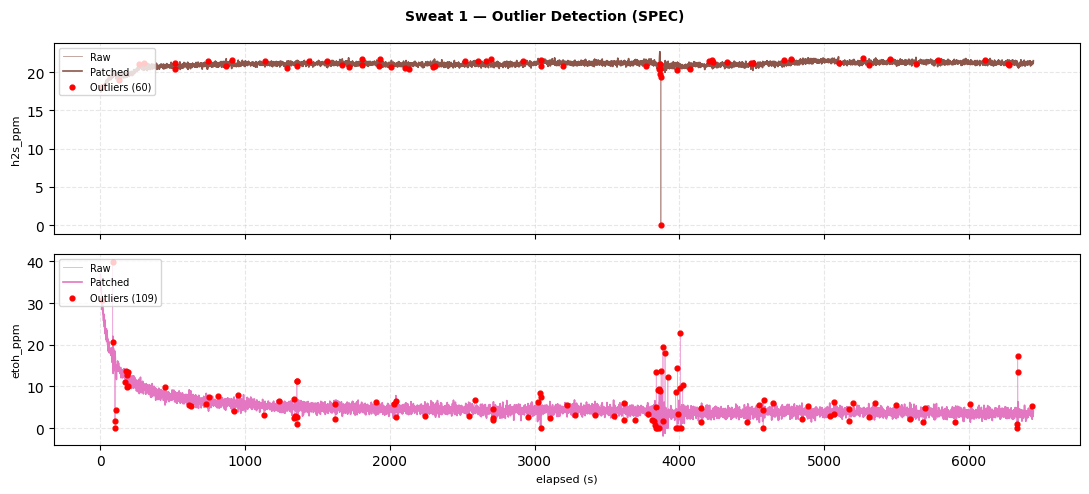

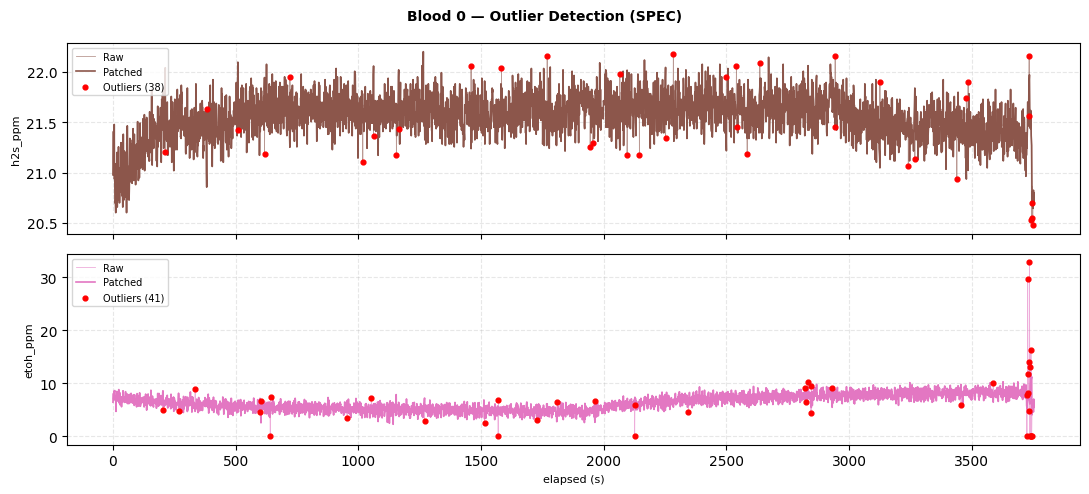

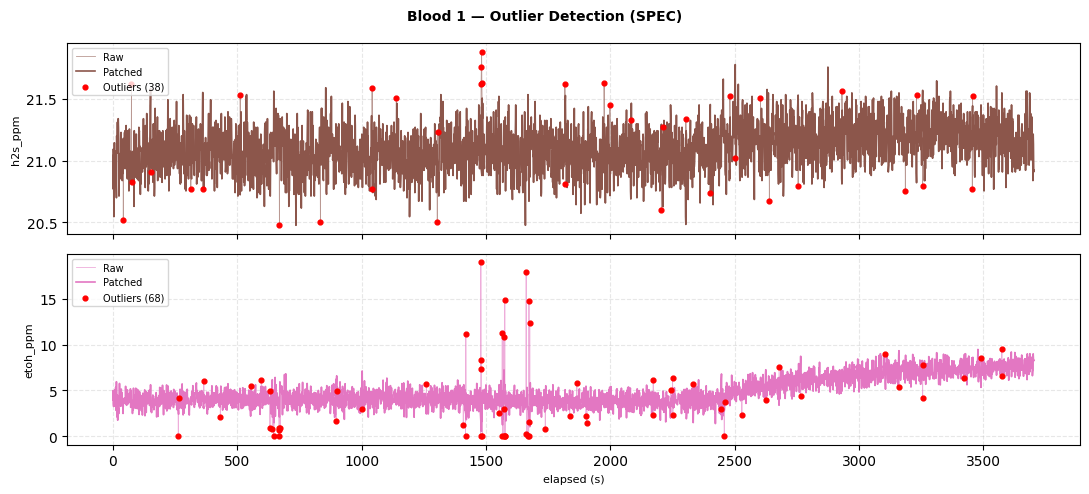

In [210]:
for name, df in datasets.items():
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — Outlier Detection (SPEC)", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        color = COLORS[col]
        info  = outlier_info[name][col]
        mask  = info["mask"]

        ax.plot(df["elapsed_s"], df[col], color=color, linewidth=0.6, alpha=0.6, label="Raw")
        ax.plot(df["elapsed_s"], info["patched"], color=color, linewidth=1.2, label="Patched")
        ax.scatter(
            df.loc[mask, "elapsed_s"], df.loc[mask, col],
            color="red", s=12, zorder=5, label=f"Outliers ({mask.sum()})",
        )
        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

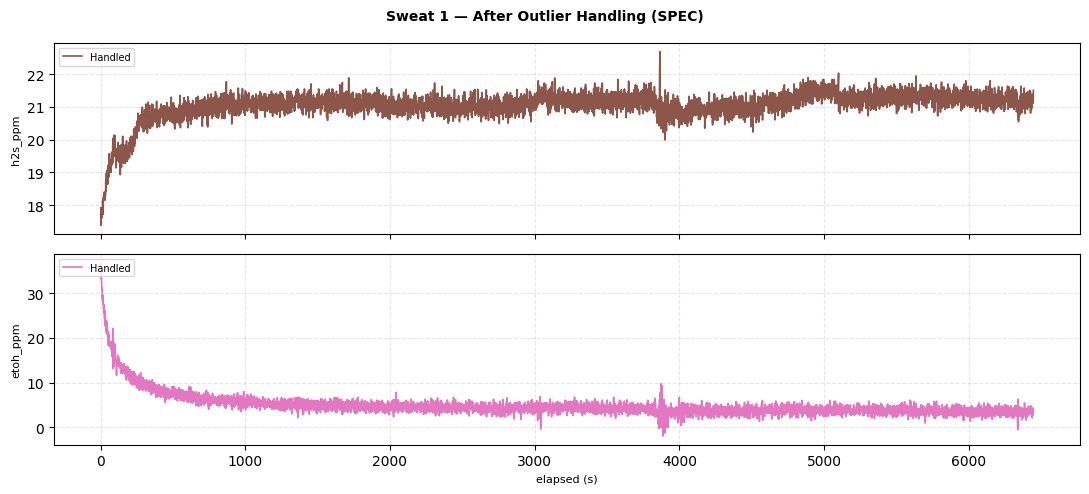

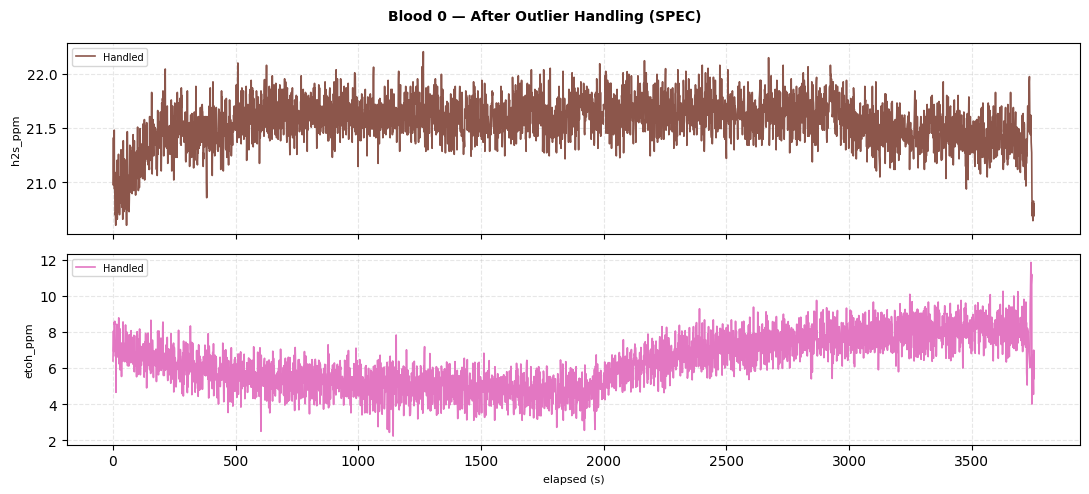

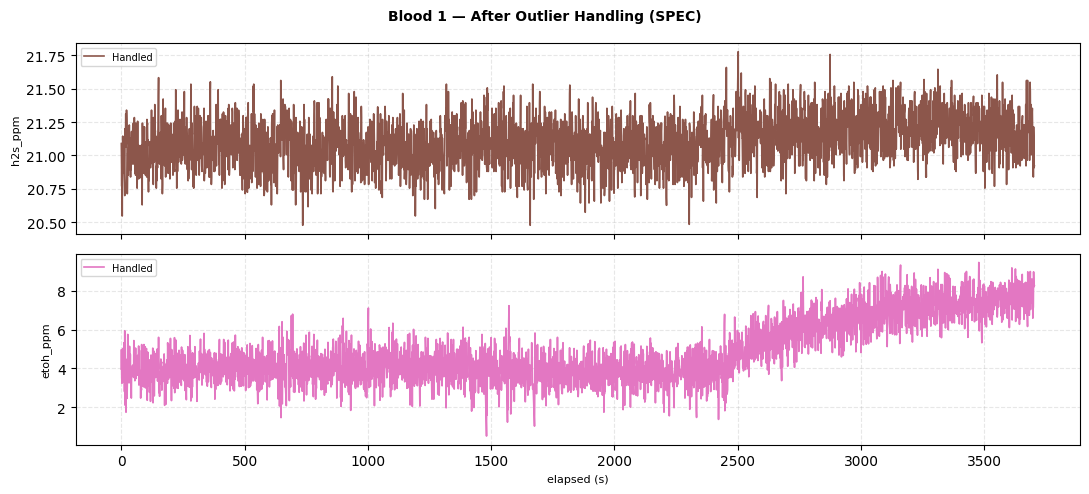

In [211]:
for name, df in datasets.items():
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — After Outlier Handling (SPEC)", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        color = COLORS[col]
        info  = outlier_info[name][col]

        ax.plot(df["elapsed_s"], info["patched"],
                color=color, linewidth=1.2, label="Handled")
        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

## Filtered Visualization

Input to both filters is the **outlier-handled signal** (not raw). Both are overlaid on the handled signal for comparison.

| Filter | Causal? | Notes |
|--------|---------|-------|
| Savitzky-Golay | No (uses a symmetric window) | Better shape preservation, less phase distortion |
| Butterworth `lfilter` | Yes | Sharper frequency cutoff, introduces phase lag |

In [212]:
from scipy.signal import savgol_filter, butter, lfilter, lfilter_zi

# ── Smoothing params 
SG_WINDOW = 121    # must be odd
SG_POLY   = 3     

BW_CUTOFF = 0.005  
BW_ORDER  = 4      
BW_FS     = 1.0    

def apply_sg(series: pd.Series, window: int = SG_WINDOW, poly: int = SG_POLY) -> pd.Series:
    return pd.Series(
        savgol_filter(series.values, window_length=window, polyorder=poly),
        index=series.index,
    )

def apply_butterworth(series: pd.Series, cutoff: float = BW_CUTOFF,
                      fs: float = BW_FS, order: int = BW_ORDER) -> pd.Series:
    nyq = fs / 2
    b, a = butter(order, cutoff / nyq, btype="low")
    zi = lfilter_zi(b, a) * series.values[0]
    out, _ = lfilter(b, a, series.values, zi=zi)
    return pd.Series(out, index=series.index)

def apply_two_stage(series: pd.Series, sg_window: int = SG_WINDOW, sg_poly: int = SG_POLY,
                    bw_cutoff: float = BW_CUTOFF) -> pd.Series:
    """SG pre-smoother removes rapid noise, Butterworth then extracts the clean trend."""
    return apply_butterworth(apply_sg(series, window=sg_window, poly=sg_poly), cutoff=bw_cutoff)

def apply_three_stage(series: pd.Series, sg_window: int = SG_WINDOW, sg_poly: int = SG_POLY,
                      bw_cutoff: float = BW_CUTOFF) -> pd.Series:
    """
    SG → Butterworth → Butterworth.
    The second BW pass squares the transfer function: same cutoff frequency,
    but double the rolloff steepness — kills slow oscillations that slip through
    a single pass without adding more phase lag than necessary.
    """
    sg_out  = apply_sg(series, window=sg_window, poly=sg_poly)
    bw_out1 = apply_butterworth(sg_out,  cutoff=bw_cutoff)
    return   apply_butterworth(bw_out1, cutoff=bw_cutoff)

# ── Per-dataset filter config (SPEC only) 
FILTER_CONFIG = {
    "Sweat 1": {"sg_window": 121, "sg_poly": 3, "bw_cutoff": 0.005},
    "Blood 0": {"sg_window": 121, "sg_poly": 3, "bw_cutoff": 0.005},
    "Blood 1": {"sg_window": 121, "sg_poly": 3, "bw_cutoff": 0.005},
}

# ── Apply filters to the outlier-handled signal (SPEC only) ──────────────────
filtered = {}
for name, df in datasets.items():
    cfg = FILTER_CONFIG[name]
    filtered[name] = {}
    for col in SPEC:
        handled = outlier_info[name][col]["patched"]
        filtered[name][col] = {
            "handled":    handled,
            "sg":         apply_sg(handled, window=cfg["sg_window"], poly=cfg["sg_poly"]),
            "butterworth": apply_butterworth(handled, cutoff=cfg["bw_cutoff"]),
            "two_stage":   apply_two_stage(handled, sg_window=cfg["sg_window"],
                                           sg_poly=cfg["sg_poly"], bw_cutoff=cfg["bw_cutoff"]),
            "three_stage": apply_three_stage(handled, sg_window=cfg["sg_window"],
                                             sg_poly=cfg["sg_poly"], bw_cutoff=cfg["bw_cutoff"]),
        }

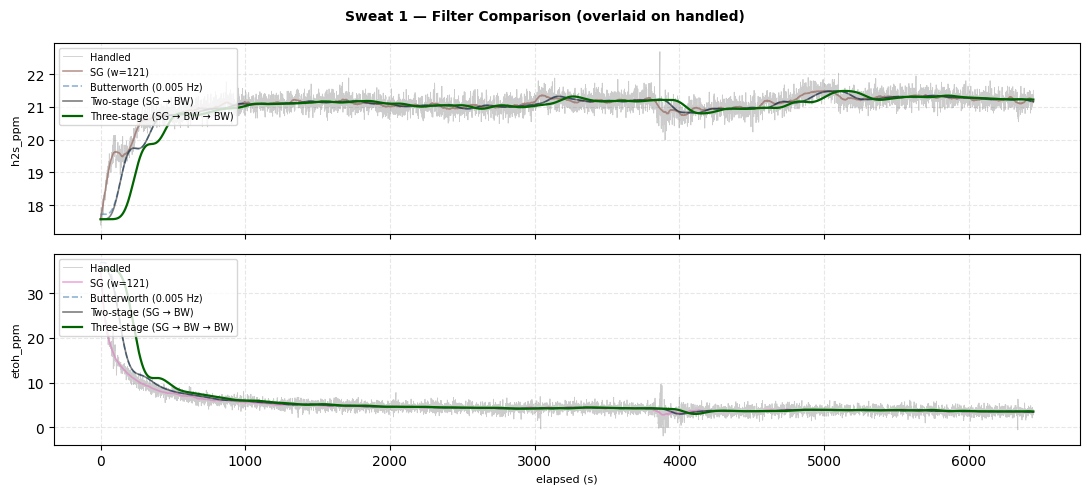

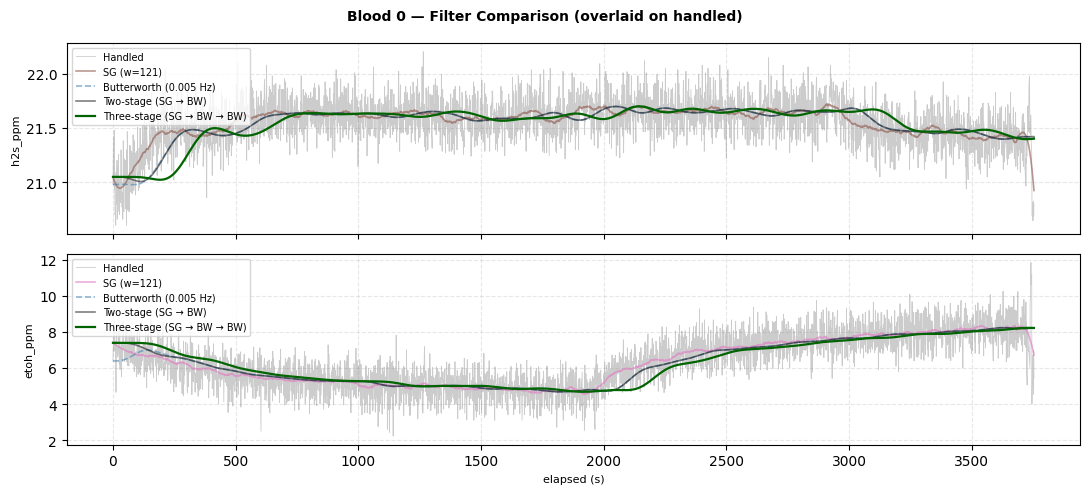

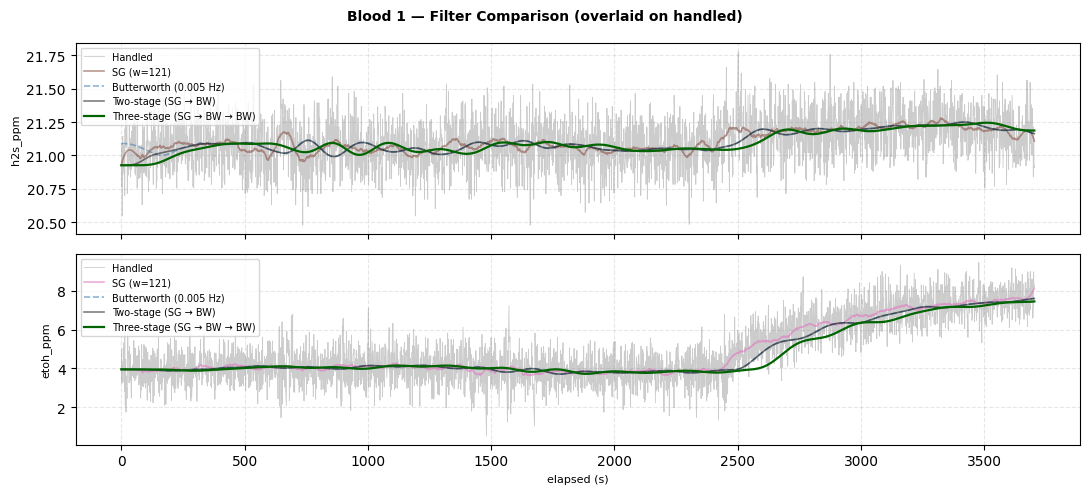

In [213]:
for name, df in datasets.items():
    cfg = FILTER_CONFIG[name]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — Filter Comparison (overlaid on handled)", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        color = COLORS[col]
        data  = filtered[name][col]
        t     = df["elapsed_s"]

        ax.plot(t, data["handled"],     color="gray",      linewidth=0.6, alpha=0.4, label="Handled")
        ax.plot(t, data["sg"],          color=color,       linewidth=1.2, alpha=0.6, label=f"SG (w={cfg['sg_window']})")
        ax.plot(t, data["butterworth"], color="steelblue", linewidth=1.2, alpha=0.6, linestyle="--", label=f"Butterworth ({cfg['bw_cutoff']} Hz)")
        ax.plot(t, data["two_stage"],   color="black",     linewidth=1.2, alpha=0.5, label="Two-stage (SG → BW)")
        ax.plot(t, data["three_stage"], color="darkgreen", linewidth=1.6,            label="Three-stage (SG → BW → BW)")
        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

## Customization: Offset, Adjustment and Smoothing

Per-dataset manual tuning applied after filtering. Each item is addressed in order:

1. **Sample event markers** — vertical lines at known times when samples were introduced, from session notes.
2. **Boot-up stabilization detection** — determine when the sensor has settled after power-on using a moving average of the per-sample rate of change. The sensor is considered stable when that rolling slope stays below a threshold for a minimum hold window. Everything before that point should not be used for classification.

In [214]:
# ── Sample introduction events (from README) ─────────────────────────────────
# Times are in elapsed seconds from recording start.
# Blood 0 / Blood 1 introduction time: not in README — determine from humidity spike.
SAMPLE_EVENTS = {
    "Sweat 1": [
        (2850, "Sweat"),
        (3850, "Reset"),
        (4600, "Sweat"),
    ],
    "Blood 0": [
        (1950, "Blood"),
    ],
    "Blood 1": [
        (2450, "Blood"),
    ],
}

EVENT_COLORS = ["tab:gray", "tab:green", "tab:orange", "tab:purple"]

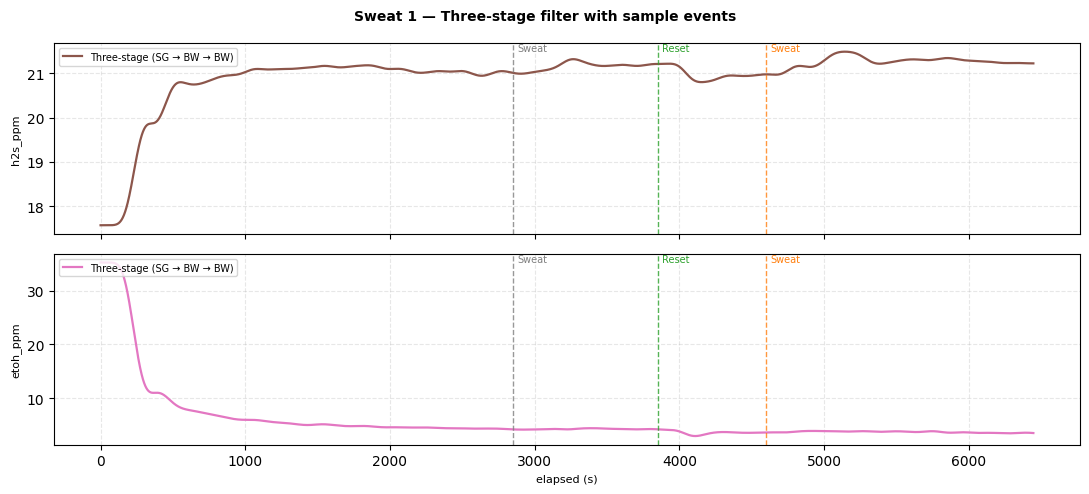

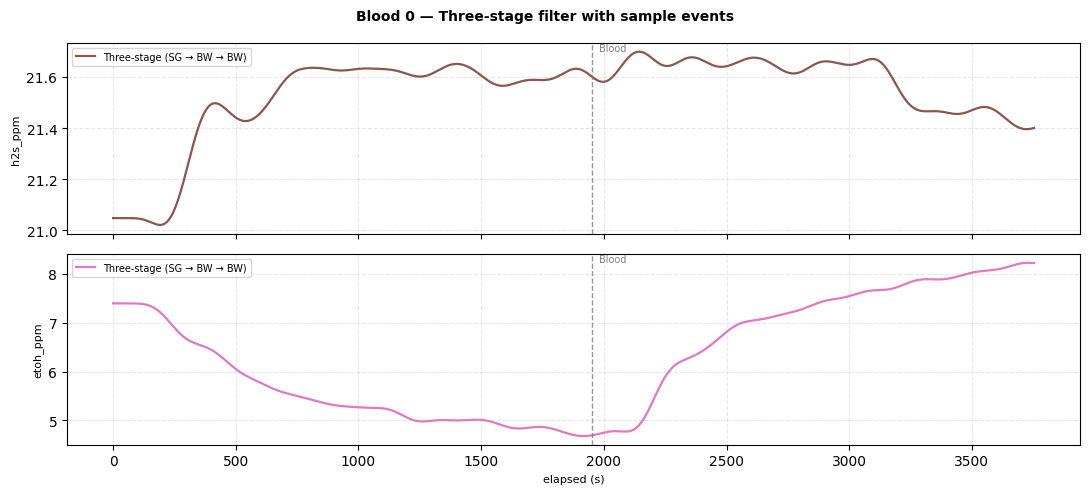

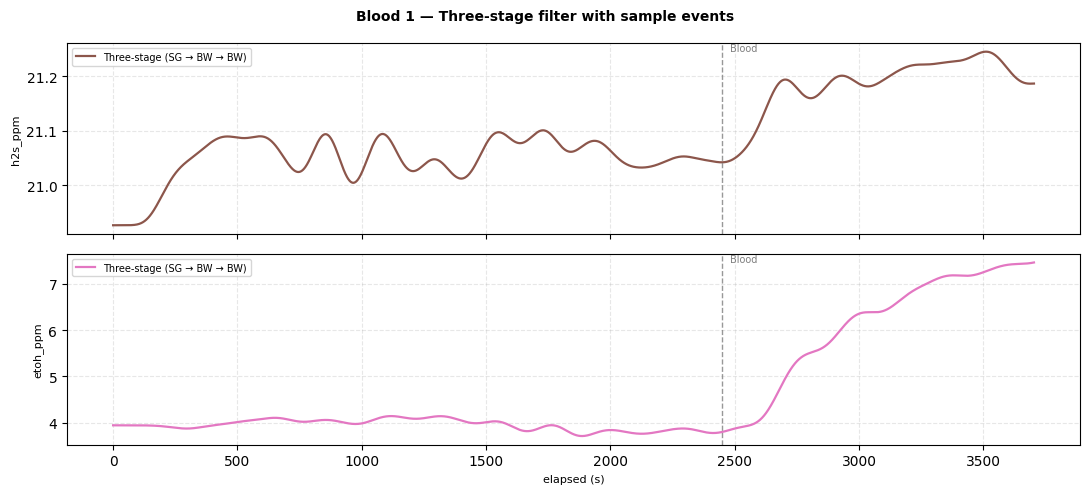

In [215]:
for name, df in datasets.items():
    events = SAMPLE_EVENTS.get(name, [])
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — Three-stage filter with sample events", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        data = filtered[name][col]
        t    = df["elapsed_s"]
        ax.plot(t, data["three_stage"], color=COLORS[col], linewidth=1.6, label="Three-stage (SG → BW → BW)")

        for (t_event, label), color in zip(events, EVENT_COLORS):
            ax.axvline(t_event, color=color, linewidth=1.0, linestyle="--", alpha=0.8)
            ax.text(t_event + 30, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
                    label, fontsize=7, color=color, va="top", clip_on=True)

        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

### Boot-up Stabilization Detection

After power-on, sensors drift significantly before settling. H2S and EtOH have fundamentally different stabilization behaviours, so each uses a dedicated algorithm:

**H2S — dual moving average convergence** (on handled signal):
- Computes a short-term MA (60 s) and long-term MA (300 s).
- During warmup the two MAs diverge; once the signal flattens they converge.
- Stable = `|short_MA − long_MA| < threshold` holds for `hold_window` consecutive seconds.

**EtOH — rolling slope threshold** (on three-stage filtered signal):
- EtOH follows an exponential decay from a high boot value — the dual MA gap never closes fast enough.
- The three-stage filter is smooth enough that per-sample |Δ| genuinely reflects the decay rate.
- Stable = rolling mean of |Δ| over a long window drops below `slope_thresh` for `hold_window` seconds.

In [216]:
# ── H2S: dual moving average convergence ─────────────────────────────────────
def detect_stabilization_h2s(series: pd.Series,
                              short_window: int = 60,
                              long_window:  int = 300,
                              threshold:    float = 0.05,
                              hold_window:  int = 300,
                              min_start:    int = 1200) -> int | None:
    """
    Dual MA convergence on the outlier-handled signal.
    Stable when |short_MA − long_MA| < threshold for hold_window consecutive samples.
    min_start: ignore the first N samples — sensor is guaranteed unstable during warmup.
    """
    short_ma = series.rolling(window=short_window, min_periods=1).mean()
    long_ma  = series.rolling(window=long_window,  min_periods=1).mean()
    is_flat  = (short_ma - long_ma).abs() < threshold

    count = 0
    for i in range(len(is_flat)):
        if i < min_start:
            count = 0
            continue
        if is_flat.iloc[i]:
            count += 1
            if count >= hold_window:
                return i - hold_window + 1
        else:
            count = 0
    return None


# ── EtOH: rolling slope threshold ────────────────────────────────────────────
def detect_stabilization_etoh(series: pd.Series,
                               slope_window: int = 300,
                               slope_thresh: float = 0.003,
                               hold_window:  int = 300,
                               min_start:    int = 1200) -> int | None:
    """
    Rolling slope threshold on the three-stage filtered signal.
    EtOH decays exponentially from a high boot value — the slope threshold
    catches the point where the decay has flattened out sufficiently.
    min_start: ignore the first N samples — sensor is guaranteed unstable during warmup.
    """
    rolling_slope = series.diff().abs().rolling(window=slope_window, min_periods=1).mean()
    is_flat = rolling_slope < slope_thresh

    count = 0
    for i in range(len(is_flat)):
        if i < min_start:
            count = 0
            continue
        if is_flat.iloc[i]:
            count += 1
            if count >= hold_window:
                return i - hold_window + 1
        else:
            count = 0
    return None


# ── Per-channel config ────────────────────────────────────────────────────────
H2S_STAB_CONFIG  = {"short_window": 60, "long_window": 300, "threshold": 0.05,
                    "hold_window": 300, "min_start": 1200}
ETOH_STAB_CONFIG = {"slope_window": 300, "slope_thresh": 0.003,
                    "hold_window": 300, "min_start": 1200}

# ── Sweat 1 split: pre-reset only ────────────────────────────────────────────
# Sweat 1 has a Reset event at 4600s (sensor was NOT power-cycled — same boot).
# The second sweat sample (4600s+) was recorded in the same boot session and
# the sensor was already stable. Run stabilization detection only on the
# pre-reset portion; the detected offset applies to the entire session.
SWEAT_1_RESET_S = 4000

# ── Detect and report ─────────────────────────────────────────────────────────
stab_results = {}
for name, df in datasets.items():
    stab_results[name] = {}

    # For Sweat 1: trim signals to pre-reset for detection only
    if name == "Sweat 1":
        pre_mask    = df["elapsed_s"] <= SWEAT_1_RESET_S
        h2s_signal  = outlier_info[name]["h2s_ppm"]["patched"][pre_mask].reset_index(drop=True)
        etoh_signal = filtered[name]["etoh_ppm"]["three_stage"][pre_mask].reset_index(drop=True)
        t_series    = df["elapsed_s"][pre_mask].reset_index(drop=True)
    else:
        h2s_signal  = outlier_info[name]["h2s_ppm"]["patched"]
        etoh_signal = filtered[name]["etoh_ppm"]["three_stage"]
        t_series    = df["elapsed_s"]

    idx = detect_stabilization_h2s(h2s_signal, **H2S_STAB_CONFIG)
    t_h2s = t_series.iloc[idx] if idx is not None else None
    stab_results[name]["h2s_ppm"] = t_h2s
    print(f"{name:8}  h2s_ppm   stabilizes at: {f'{t_h2s:.0f} s' if t_h2s is not None else 'not detected'}")

    idx = detect_stabilization_etoh(etoh_signal, **ETOH_STAB_CONFIG)
    t_etoh = t_series.iloc[idx] if idx is not None else None
    stab_results[name]["etoh_ppm"] = t_etoh
    print(f"{name:8}  etoh_ppm  stabilizes at: {f'{t_etoh:.0f} s' if t_etoh is not None else 'not detected'}")


Sweat 1   h2s_ppm   stabilizes at: 2631 s
Sweat 1   etoh_ppm  stabilizes at: 1228 s
Blood 0   h2s_ppm   stabilizes at: 2044 s
Blood 0   etoh_ppm  stabilizes at: 1229 s
Blood 1   h2s_ppm   stabilizes at: 1666 s
Blood 1   etoh_ppm  stabilizes at: 1228 s


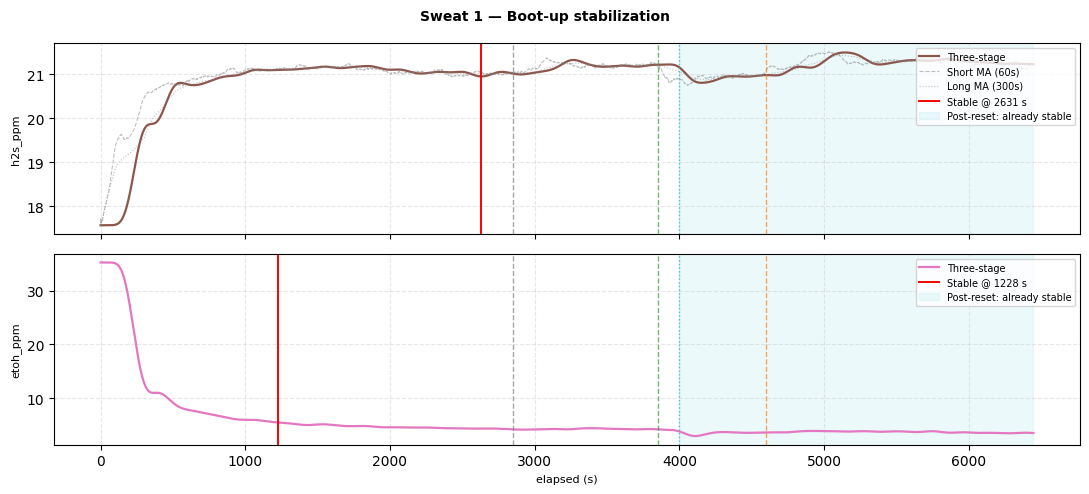

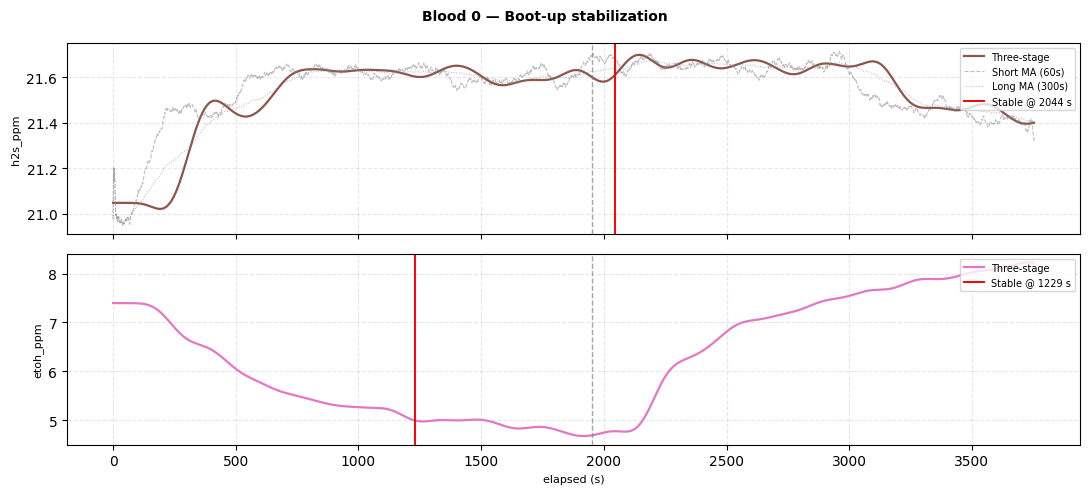

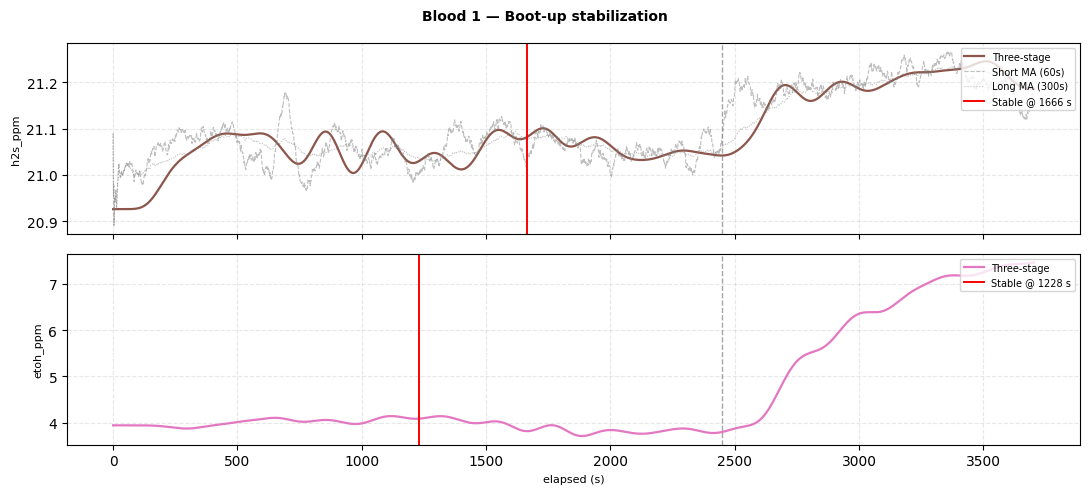

In [217]:
for name, df in datasets.items():
    events = SAMPLE_EVENTS.get(name, [])
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — Boot-up stabilization", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        three_s  = filtered[name][col]["three_stage"]
        handled  = outlier_info[name][col]["patched"]
        t        = df["elapsed_s"]
        t_stable = stab_results[name][col]

        ax.plot(t, three_s, color=COLORS[col], linewidth=1.6, label="Three-stage")

        # Show MAs for H2S, slope signal for EtOH
        if col == "h2s_ppm":
            short_ma = handled.rolling(window=H2S_STAB_CONFIG["short_window"], min_periods=1).mean()
            long_ma  = handled.rolling(window=H2S_STAB_CONFIG["long_window"],  min_periods=1).mean()
            ax.plot(t, short_ma, color="gray", linewidth=0.8, alpha=0.5, linestyle="--",
                    label=f"Short MA ({H2S_STAB_CONFIG['short_window']}s)")
            ax.plot(t, long_ma,  color="gray", linewidth=0.8, alpha=0.5, linestyle=":",
                    label=f"Long MA ({H2S_STAB_CONFIG['long_window']}s)")

        # Sample event lines
        for (t_event, label), color in zip(events, EVENT_COLORS):
            ax.axvline(t_event, color=color, linewidth=1.0, linestyle="--", alpha=0.7)

        # Stabilization marker
        if t_stable is not None:
            ax.axvline(t_stable, color="red", linewidth=1.4, linestyle="-",
                       label=f"Stable @ {t_stable:.0f} s")
        else:
            ax.text(0.5, 0.5, "Not detected", transform=ax.transAxes,
                    fontsize=9, color="red", ha="center", va="center", alpha=0.6)

        # For Sweat 1: shade the post-reset region as already-stable
        if name == "Sweat 1":
            t_end = t.iloc[-1]
            ax.axvspan(SWEAT_1_RESET_S, t_end, color="tab:cyan", alpha=0.08,
                       label=f"Post-reset: already stable")
            ax.axvline(SWEAT_1_RESET_S, color="tab:cyan", linewidth=1.0,
                       linestyle=":", alpha=0.8)

        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


In [218]:
# ── Apply stabilization offset ────────────────────────────────────────────────
# The stable baseline value at the detected stabilization point is used as a
# per-boot offset. Subtract it from the three-stage signal so readings start
# from 0 at the point of stability. Clipped at 0 (no negative ppm).

offset_results = {}   # {name: {col: {"offset": float, "signal": Series}}}

for name, df in datasets.items():
    offset_results[name] = {}
    for col in SPEC:
        signal   = filtered[name][col]["three_stage"]
        t_stable = stab_results[name][col]

        if t_stable is not None:
            # Index of stabilization point
            stab_idx = (df["elapsed_s"] - t_stable).abs().argmin()
            baseline = signal.iloc[stab_idx]
        else:
            # Fallback: use mean of last 300 samples before any known event
            baseline = signal.iloc[:300].mean()

        corrected = (signal - baseline).clip(lower=0)
        offset_results[name][col] = {"offset": baseline, "signal": corrected}
        print(f"{name:8}  {col:10}  baseline offset = {baseline:.4f} ppm")

Sweat 1   h2s_ppm     baseline offset = 20.9446 ppm
Sweat 1   etoh_ppm    baseline offset = 5.5145 ppm
Blood 0   h2s_ppm     baseline offset = 21.6083 ppm
Blood 0   etoh_ppm    baseline offset = 4.9974 ppm
Blood 1   h2s_ppm     baseline offset = 21.0822 ppm
Blood 1   etoh_ppm    baseline offset = 4.0905 ppm


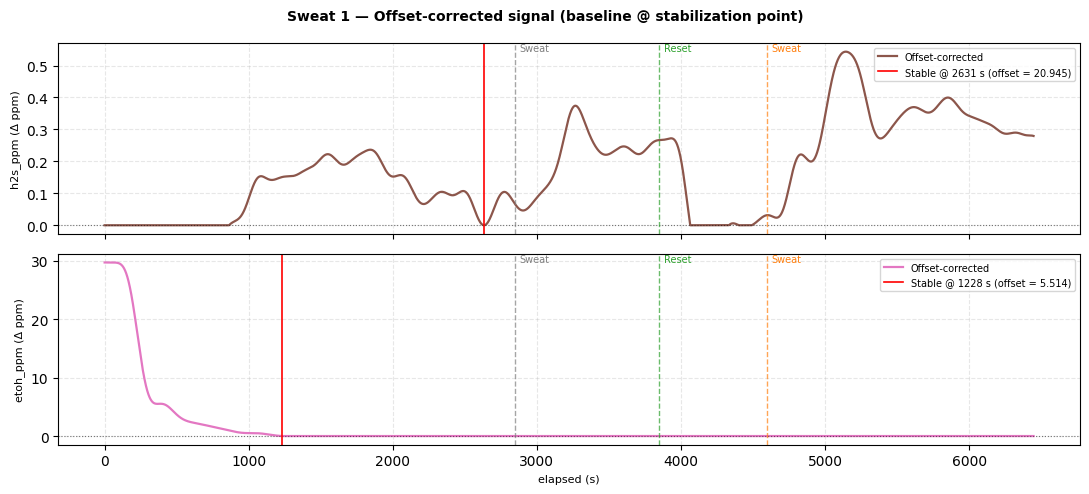

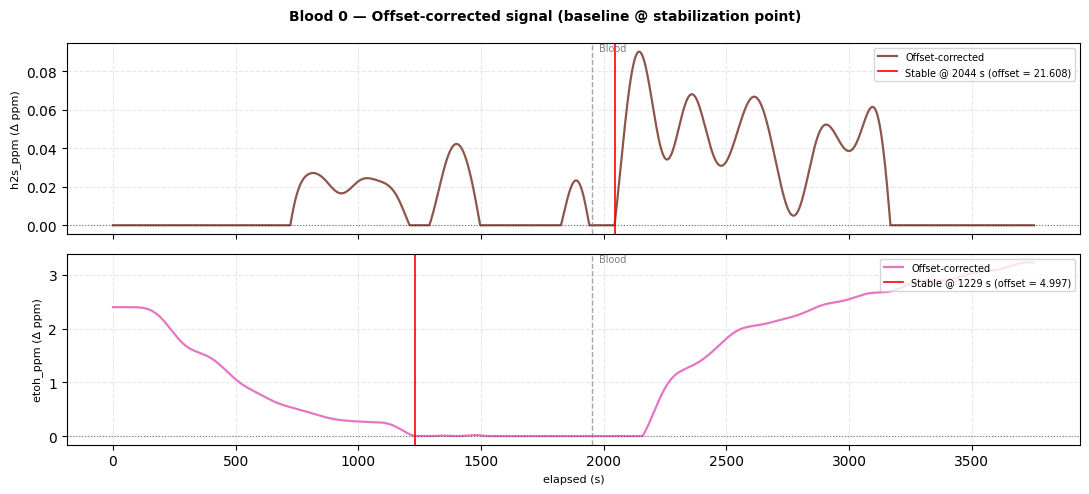

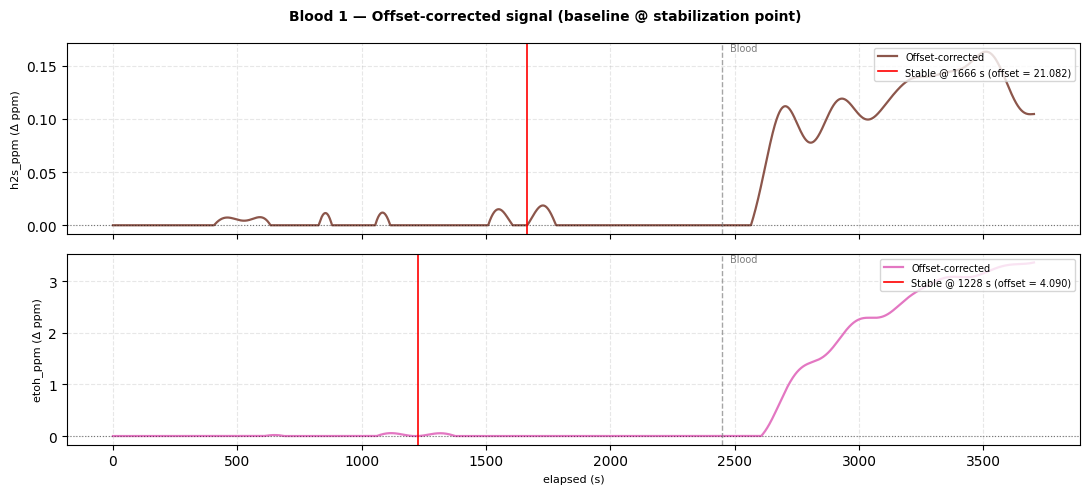

In [219]:
for name, df in datasets.items():
    events   = SAMPLE_EVENTS.get(name, [])
    t_stable = stab_results[name]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{name} — Offset-corrected signal (baseline @ stabilization point)",
                 fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        data = offset_results[name][col]
        t    = df["elapsed_s"]

        ax.plot(t, data["signal"], color=COLORS[col], linewidth=1.6, label="Offset-corrected")
        ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.5)

        # Stabilization marker
        t_stab = t_stable[col]
        if t_stab is not None:
            ax.axvline(t_stab, color="red", linewidth=1.2, linestyle="-",
                       label=f"Stable @ {t_stab:.0f} s (offset = {data['offset']:.3f})")

        # Sample event lines
        for (t_event, label), color in zip(events, EVENT_COLORS):
            ax.axvline(t_event, color=color, linewidth=1.0, linestyle="--", alpha=0.7)
            ax.text(t_event + 30, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
                    label, fontsize=7, color=color, va="top", clip_on=True)

        ax.set_ylabel(f"{col} (Δ ppm)", fontsize=8)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

### Sweat 1 — Split into 1a and 1b

The Sweat 1 session contains two distinct sample introductions separated by a **Reset at 4000 s** (data recording was restarted, but the sensor remained powered — same boot):

| Sub-dataset | Time range (elapsed) | Sample |
|-------------|----------------------|--------|
| **Sweat 1a** | 0 – 4000 s | Sweat samples (2, 3) introduced at 3850 s |
| **Sweat 1b** | starts at reset (0 s) | Sweat sample (1) introduced at 1750 s |

Since the sensor was already stable when Sweat 1b was recorded, no separate boot-up stabilization is needed. The same baseline offset from Sweat 1a applies.

Sweat 1a: 3909 samples  (0 – 4000 s)
Sweat 1b: 2390 samples  (0 – 2446 s)


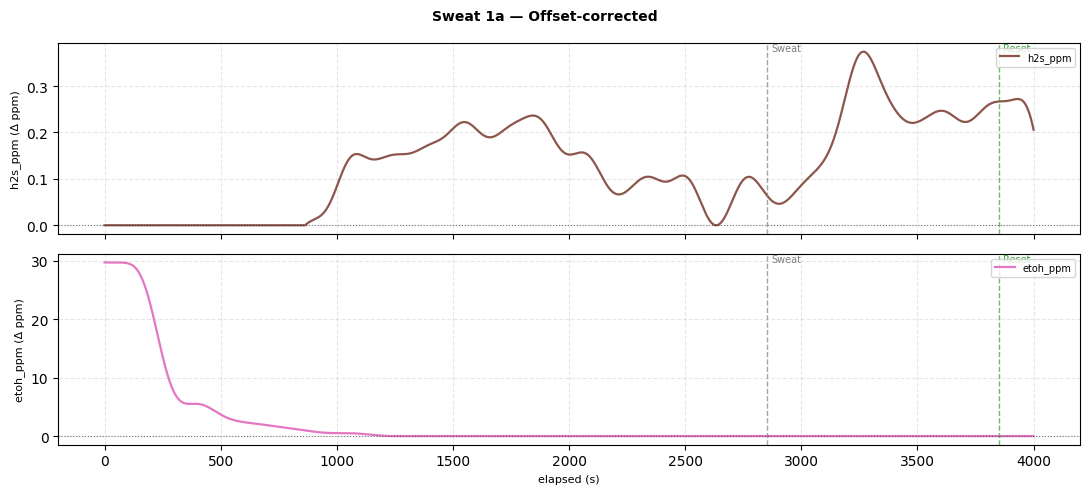

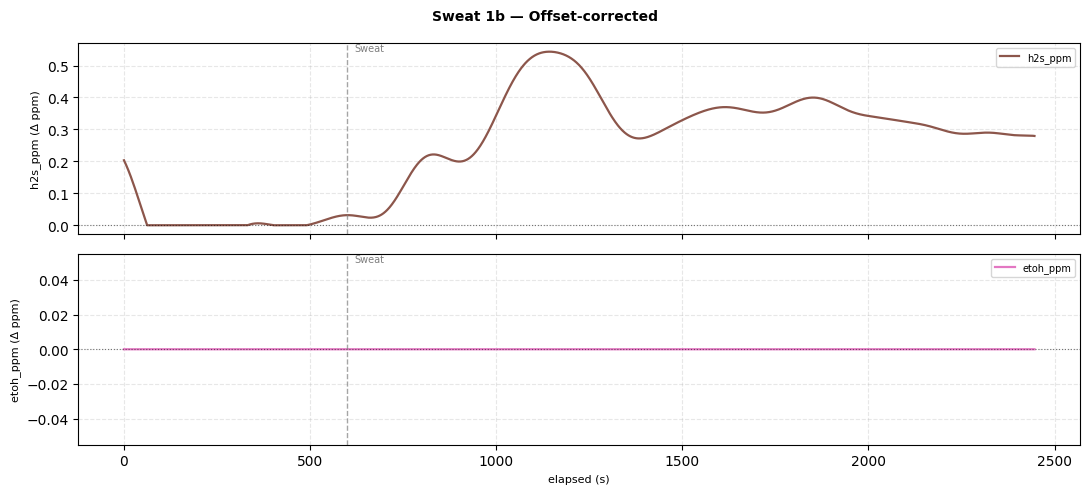

In [220]:
# ── Sweat 1 → 1a / 1b split (post offset-correction) ─────────────────────────
# Split is done on the offset-corrected signals in offset_results.
# Sweat 1b elapsed_s is reset to 0 from the Reset event (4600s).
# No trim applied — 1b starts right at the reset point.

df_sw1 = datasets["Sweat 1"]
t_sw1  = df_sw1["elapsed_s"]

mask_1a = t_sw1 <= SWEAT_1_RESET_S
mask_1b = t_sw1 >  SWEAT_1_RESET_S

def _make_split(mask, reset_t0=False):
    t = t_sw1[mask].reset_index(drop=True)
    if reset_t0:
        t = t - t.iloc[0]
    sigs = {col: offset_results["Sweat 1"][col]["signal"][mask].reset_index(drop=True)
            for col in SPEC}
    return {"elapsed_s": t, **sigs}

sweat_1a = _make_split(mask_1a)
sweat_1b = _make_split(mask_1b, reset_t0=True)

print(f"Sweat 1a: {len(sweat_1a['elapsed_s'])} samples  "
      f"({sweat_1a['elapsed_s'].iloc[0]:.0f} – {sweat_1a['elapsed_s'].iloc[-1]:.0f} s)")
print(f"Sweat 1b: {len(sweat_1b['elapsed_s'])} samples  "
      f"({sweat_1b['elapsed_s'].iloc[0]:.0f} – {sweat_1b['elapsed_s'].iloc[-1]:.0f} s)")

# ── Events re-aligned to sub-dataset elapsed_s ────────────────────────────────
EVENTS_1A = [(t, lbl) for t, lbl in SAMPLE_EVENTS["Sweat 1"] if t <= SWEAT_1_RESET_S]
EVENTS_1B = [(t - SWEAT_1_RESET_S, lbl)
             for t, lbl in SAMPLE_EVENTS["Sweat 1"] if t > SWEAT_1_RESET_S]

# ── Visualize ─────────────────────────────────────────────────────────────────
for sub_name, sub_data, events in [
    ("Sweat 1a", sweat_1a, EVENTS_1A),
    ("Sweat 1b", sweat_1b, EVENTS_1B),
]:
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    fig.suptitle(f"{sub_name} — Offset-corrected", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, SPEC):
        t = sub_data["elapsed_s"]
        ax.plot(t, sub_data[col], color=COLORS[col], linewidth=1.6, label=col)
        ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.5)

        for (t_event, label), color in zip(events, EVENT_COLORS):
            ax.axvline(t_event, color=color, linewidth=1.0, linestyle="--", alpha=0.7)
            ax.text(t_event + 20, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.1,
                    label, fontsize=7, color=color, va="top", clip_on=True)

        ax.set_ylabel(f"{col} (Δ ppm)", fontsize=8)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


In [221]:
import os
import pandas as pd

os.makedirs("processed", exist_ok=True)

# ── Sweat 1a and 1b (from sweat_split_code) ───────────────────────────────────
for fname, data in [("spec_sweat_1a", sweat_1a), ("spec_sweat_1b", sweat_1b)]:
    df = pd.DataFrame({
        "elapsed_s": data["elapsed_s"],
        "h2s_ppm":   data["h2s_ppm"],
        "etoh_ppm":  data["etoh_ppm"],
    })
    path = f"processed/{fname}.pkl"
    df.to_pickle(path)
    print(f"Saved {path}  ({len(df)} rows)")

# ── Blood 0 and Blood 1 ───────────────────────────────────────────────────────
for ds_name, fname in [("Blood 0", "spec_blood_0"), ("Blood 1", "spec_blood_1")]:
    df_raw = datasets[ds_name]
    df = pd.DataFrame({
        "elapsed_s": df_raw["elapsed_s"].values,
        "h2s_ppm":   offset_results[ds_name]["h2s_ppm"]["signal"].values,
        "etoh_ppm":  offset_results[ds_name]["etoh_ppm"]["signal"].values,
    })
    path = f"processed/{fname}.pkl"
    df.to_pickle(path)
    print(f"Saved {path}  ({len(df)} rows)")


Saved processed/spec_sweat_1a.pkl  (3909 rows)
Saved processed/spec_sweat_1b.pkl  (2390 rows)
Saved processed/spec_blood_0.pkl  (3666 rows)
Saved processed/spec_blood_1.pkl  (3618 rows)


### Validation — H2S

Apply the full pipeline (PPM calculation → outlier detection + handling → SG + Butterworth) to the known calibration run.

- **PPM offset**: 15.9215 ppm (from `offset_h2s.py`, subtracted after division)
- **Vref**: mean over the run (stable during calibration — not drifting)

In [222]:
H2S_OFFSET_PPM = 15.9215   # ppm — subtracted after division (from offset_h2s.py)

# ── Load validation data ──────────────────────────────────────────────────────
val = pd.read_csv(VALIDATION, parse_dates=["wall_time"])
val["elapsed_s"] = (val["wall_time"] - val["wall_time"].iloc[0]).dt.total_seconds()
for col in VGAS_COLS:
    val[col] = pd.to_numeric(val[col], errors="coerce")

# Mean Vref — stable during calibration run, averaging removes noise on reference electrode
val_vref_mean = val["h2s_vref"].mean()
val["h2s_ppm"] = (
    ((val["h2s_vgas"] - val_vref_mean) / M_H2S) - H2S_OFFSET_PPM
).clip(lower=0) * H2S_SCALE

# ── Outlier detection + handling ─────────────────────────────────────────────
val_mask_iqr = detect_outliers_iqr(val["h2s_ppm"])
val_mask_roc = detect_outliers_roc(val["h2s_ppm"])
val_mask     = val_mask_iqr | val_mask_roc
val_handled  = handle_outliers(val["h2s_ppm"], val_mask)

# ── Apply filters ─────────────────────────────────────────────────────────────
val_sg = apply_sg(val_handled)
val_bw = apply_butterworth(val_handled)

print(f"Validation rows  : {len(val)}")
print(f"Vref mean        : {val_vref_mean:.4f} V")
print(f"Outliers flagged : {val_mask.sum()} / {len(val)} ({100*val_mask.sum()/len(val):.1f}%)")
print(f"Raw ppm range    : [{val['h2s_ppm'].min():.3f}, {val['h2s_ppm'].max():.3f}]")

Validation rows  : 2036
Vref mean        : 1.4573 V
Outliers flagged : 32 / 2036 (1.6%)
Raw ppm range    : [0.000, 7.608]


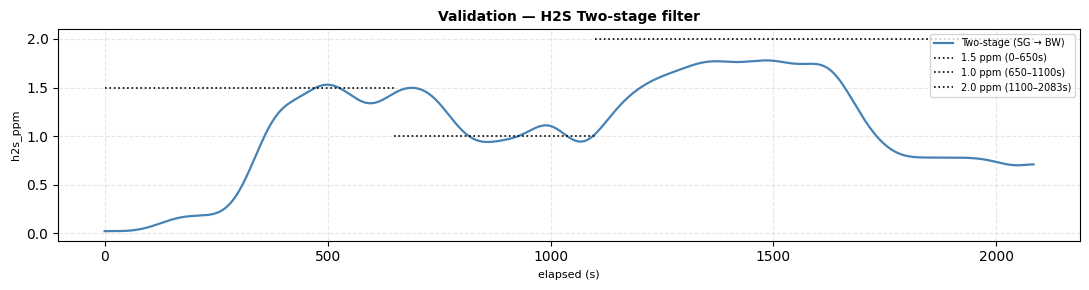

In [223]:
# Known H2S concentrations during the calibration run (from README)
REF_SEGMENTS = [
    (0,    650,  1.5),
    (650,  1100, 1.0),
    (1100, None, 2.0),
]

val_two_stage = apply_two_stage(val_handled)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(val["elapsed_s"], val_two_stage, color="steelblue", linewidth=1.6, label="Two-stage (SG → BW)")

# Segmented reference lines at known concentrations
t_max = val["elapsed_s"].iloc[-1]
for t0, t1, ppm in REF_SEGMENTS:
    t1_eff = t1 if t1 is not None else t_max
    ax.hlines(ppm, t0, t1_eff, colors="black", linewidth=1.2, linestyles=":",
              label=f"{ppm} ppm ({t0}–{int(t1_eff)}s)")

ax.set_ylabel("h2s_ppm", fontsize=8)
ax.set_xlabel("elapsed (s)", fontsize=8)
ax.set_title("Validation — H2S Two-stage filter", fontsize=10, fontweight="bold")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## Validate Data

In [224]:
BLOOD_VALIDATE_1 = "../20260331-experiment/1.5blood_1.csv"

## Validation — Apply Full Pipeline to BLOOD_VALIDATE_1

Load the held-out validation recording and apply the same pipeline used for training data:
1. PPM calculation from Vgas/Vref (same constants as training)
2. Outlier detection (IQR + ROC) and causal handling
3. Three-stage filter (SG → Butterworth → Butterworth)
4. Boot-up stabilization detection
5. Baseline offset correction

In [225]:
# ── Load ──────────────────────────────────────────────────────────────────────
blood_val = load(BLOOD_VALIDATE_1)
print(f"Loaded BLOOD_VALIDATE_1: {len(blood_val)} rows")

# ── Outlier detection + handling ──────────────────────────────────────────────
val_outlier_info = {}
for col in SPEC:
    mask_iqr = detect_outliers_iqr(blood_val[col])
    mask_roc = detect_outliers_roc(blood_val[col])
    combined = mask_iqr | mask_roc
    patched  = handle_outliers(blood_val[col], combined)
    val_outlier_info[col] = {"mask": combined, "patched": patched}
    n = combined.sum()
    print(f"  {col:10}  outliers flagged: {n:4d}  ({100*n/len(blood_val):.1f}%)")

# ── Three-stage filter ────────────────────────────────────────────────────────
val_filtered = {}
for col in SPEC:
    handled = val_outlier_info[col]["patched"]
    val_filtered[col] = {
        "handled":     handled,
        "three_stage": apply_three_stage(handled),
    }

# ── Stabilization detection ───────────────────────────────────────────────────
val_stab   = {}
t_series   = blood_val["elapsed_s"]

idx    = detect_stabilization_h2s(val_outlier_info["h2s_ppm"]["patched"], **H2S_STAB_CONFIG)
t_h2s  = t_series.iloc[idx] if idx is not None else None
val_stab["h2s_ppm"] = t_h2s
print(f"\n  h2s_ppm   stabilizes at: {f'{t_h2s:.0f} s' if t_h2s is not None else 'not detected'}")

idx    = detect_stabilization_etoh(val_filtered["etoh_ppm"]["three_stage"], **ETOH_STAB_CONFIG)
t_etoh = t_series.iloc[idx] if idx is not None else None
val_stab["etoh_ppm"] = t_etoh
print(f"  etoh_ppm  stabilizes at: {f'{t_etoh:.0f} s' if t_etoh is not None else 'not detected'}")

# ── Offset correction ─────────────────────────────────────────────────────────
val_offset = {}
for col in SPEC:
    signal   = val_filtered[col]["three_stage"]
    t_stable = val_stab[col]
    if t_stable is not None:
        stab_idx = (blood_val["elapsed_s"] - t_stable).abs().argmin()
        baseline = signal.iloc[stab_idx]
    else:
        baseline = signal.iloc[:300].mean()
    corrected = (signal - baseline).clip(lower=0)
    val_offset[col] = {"offset": baseline, "signal": corrected}
    print(f"  {col:10}  baseline offset = {baseline:.4f} ppm")

Loaded BLOOD_VALIDATE_1: 3935 rows
  h2s_ppm     outliers flagged:   46  (1.2%)
  etoh_ppm    outliers flagged:  117  (3.0%)

  h2s_ppm   stabilizes at: not detected
  etoh_ppm  stabilizes at: 1563 s
  h2s_ppm     baseline offset = 21.0241 ppm
  etoh_ppm    baseline offset = 9.1710 ppm


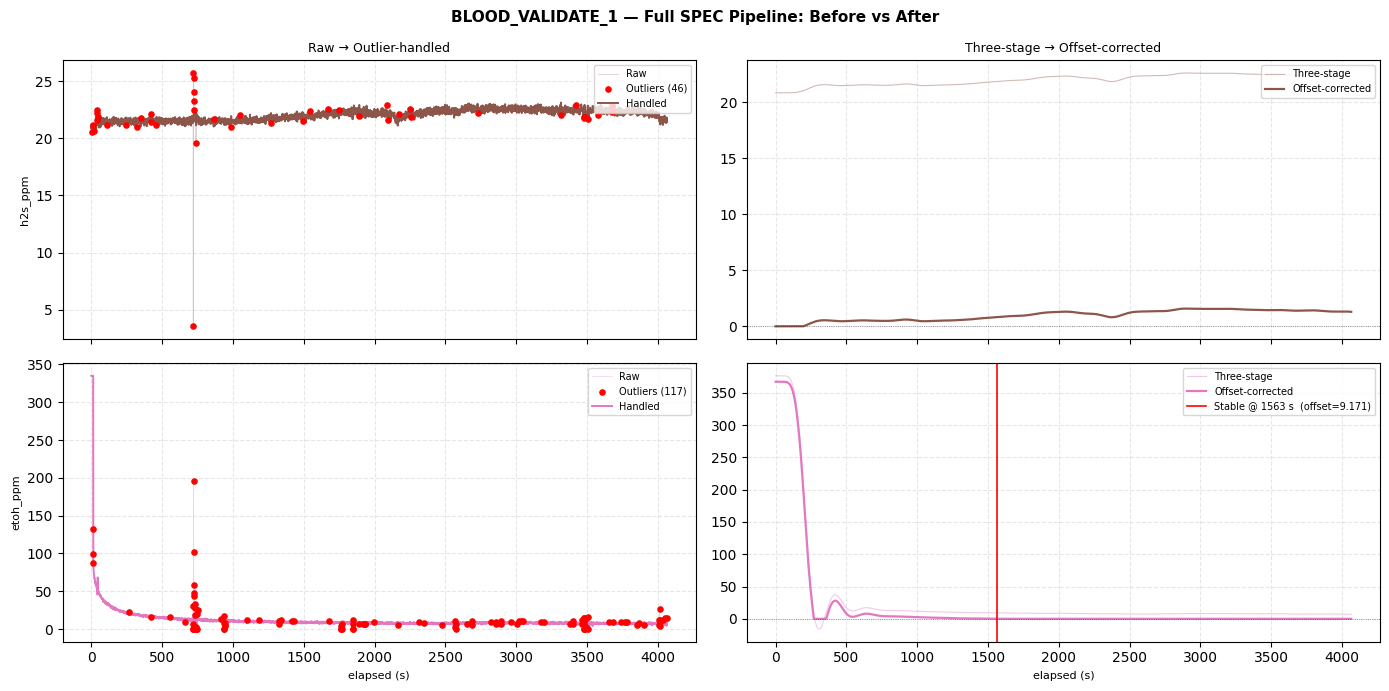

In [226]:
# ── Before / After plot ───────────────────────────────────────────────────────
# Left column : Raw (with outliers flagged) → outlier-handled
# Right column: Three-stage filtered → offset-corrected (with stabilization marker)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
fig.suptitle("BLOOD_VALIDATE_1 — Full SPEC Pipeline: Before vs After",
             fontsize=11, fontweight="bold")

for i, col in enumerate(SPEC):
    color = COLORS[col]
    t     = blood_val["elapsed_s"]
    info  = val_outlier_info[col]

    # Left: Raw (outliers marked) → outlier-handled
    ax = axes[i, 0]
    ax.plot(t, blood_val[col],     color=color, linewidth=0.5, alpha=0.35, label="Raw")
    ax.scatter(
        t[info["mask"]], blood_val[col][info["mask"]],
        color="red", s=14, zorder=5, label=f"Outliers ({info['mask'].sum()})",
    )
    ax.plot(t, info["patched"],    color=color, linewidth=1.4, label="Handled")
    ax.set_ylabel(col, fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3, linestyle="--")
    if i == 0:
        ax.set_title("Raw → Outlier-handled", fontsize=9)

    # Right: Three-stage → offset-corrected
    ax = axes[i, 1]
    ax.plot(t, val_filtered[col]["three_stage"], color=color, linewidth=0.8, alpha=0.4,
            label="Three-stage")
    ax.plot(t, val_offset[col]["signal"],        color=color, linewidth=1.6,
            label="Offset-corrected")
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
    t_stab = val_stab[col]
    if t_stab is not None:
        ax.axvline(t_stab, color="red", linewidth=1.2, linestyle="-",
                   label=f"Stable @ {t_stab:.0f} s  (offset={val_offset[col]['offset']:.3f})")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3, linestyle="--")
    if i == 0:
        ax.set_title("Three-stage → Offset-corrected", fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("elapsed (s)", fontsize=8)

plt.tight_layout()
plt.show()